#### Feature Engineering on F1-2023

In [6]:
import pandas as pd 
import fastf1
driver_df = pd.read_csv('driver_2023_cleaned.csv')
weather_df = pd.read_csv('weather_2023_cleaned.csv')
weather_df.head()

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,EventName,Session,Date
0,0 days 00:00:33.860000,27.5,11.0,1017.4,False,42.7,336.0,3.2,1,Bahrain Grand Prix,FP1,2023-03-05
1,0 days 00:01:33.859000,27.5,11.0,1017.2,False,42.6,345.0,2.7,1,Bahrain Grand Prix,FP1,2023-03-05
2,0 days 00:02:33.873000,27.6,12.0,1017.4,False,42.6,340.0,2.7,1,Bahrain Grand Prix,FP1,2023-03-05
3,0 days 00:03:33.888000,27.6,12.0,1017.2,False,42.4,342.0,2.7,1,Bahrain Grand Prix,FP1,2023-03-05
4,0 days 00:04:33.887000,27.6,12.0,1017.4,False,42.4,341.0,3.4,1,Bahrain Grand Prix,FP1,2023-03-05


In [7]:
import pandas as pd

def merge_driver_weather(driver_df, weather_df, output_csv="merged_data.csv"):
    """
    Merge driver and weather datasets on nearest timestamp within the same GP and Session.

    Parameters
    ----------
    driver_df : pd.DataFrame
        Driver dataset with columns including ['GP', 'SessionType', 'DriverTime']
    weather_df : pd.DataFrame
        Weather dataset with columns including ['EventName', 'Session', 'WeatherTime']
    output_csv : str, optional
        File path to save merged dataframe as CSV (default is 'merged_data.csv')

    Returns
    -------
    merged_df : pd.DataFrame
        Merged dataframe containing driver + weather data
    """

    # Ensure time columns are timedelta
    driver_df["DriverTime"] = pd.to_timedelta(driver_df["DriverTime"])
    weather_df["WeatherTime"] = pd.to_timedelta(weather_df["WeatherTime"])

    # Standardize session/GP column names
    driver_df = driver_df.rename(columns={"SessionType": "Session"})
    weather_df = weather_df.rename(columns={"EventName": "GP"})

    # Sort both by GP, Session, and Time
    driver_df = driver_df.sort_values(["GP", "Session", "DriverTime"]).reset_index(drop=True)
    weather_df = weather_df.sort_values(["GP", "Session", "WeatherTime"]).reset_index(drop=True)

    # Perform asof merge (nearest past weather reading per lap)
    merged_df = pd.merge_asof(
        driver_df,
        weather_df,
        left_on="DriverTime",
        right_on="WeatherTime",
        by=["GP", "Session"],
        direction="backward"
    )

    # Save to CSV
    merged_df.to_csv(output_csv, index=False)

    print(f"✅ Merge complete. Saved to {output_csv}")

    # -----------------------------
    # Sanity check: print samples
    # -----------------------------
    print("\n🔍 Sanity check (first 3 merged rows per GP & Session):")
    for (gp, session), group in merged_df.groupby(["GP", "Session"]):
        print(f"\n🏁 {gp} | {session}")
        print(group[["Driver", "LapNumber", "DriverTime", "WeatherTime", 
                     "AirTemp", "TrackTemp", "Humidity", "Rainfall"]].head(3))
    
    return merged_df


# Load cleaned datasets
driver_df = pd.read_csv("driver_2023_cleaned.csv")
weather_df = pd.read_csv("weather_2023_cleaned.csv")

# Ensure correct time column names
driver_df = driver_df.rename(columns={"Time": "DriverTime"})
weather_df = weather_df.rename(columns={"Time": "WeatherTime"})

# Convert to timedelta
driver_df["DriverTime"] = pd.to_timedelta(driver_df["DriverTime"])
weather_df["WeatherTime"] = pd.to_timedelta(weather_df["WeatherTime"])

# Sort by GP, Session, and time (VERY important for merge_asof)
driver_df = driver_df.sort_values(["GP", "SessionType", "DriverTime"]).reset_index(drop=True)
weather_df = weather_df.sort_values(["EventName", "Session", "WeatherTime"]).reset_index(drop=True)

# Now merge
merged_df = merge_driver_weather(driver_df, weather_df, output_csv="merged_driver_weather.csv")



ValueError: left keys must be sorted

In [ ]:
import pandas as pd

def merge_driver_weather(driver_df, weather_df, output_csv="merged_data.csv"):
    """
    Merge driver and weather datasets on nearest timestamp within the same GP and Session.
    """

    # --- Step 1: Standardize column names ---
    driver_df = driver_df.rename(columns={
        "Time": "DriverTime",
        "SessionType": "Session"
    })
    weather_df = weather_df.rename(columns={
        "Time": "WeatherTime",
        "EventName": "GP"
    })

    # --- Step 2: Convert time columns to timedelta ---
    driver_df["DriverTime"] = pd.to_timedelta(driver_df["DriverTime"])
    weather_df["WeatherTime"] = pd.to_timedelta(weather_df["WeatherTime"])

    # --- Step 3: Sort properly (critical for merge_asof) ---
    driver_df = driver_df.sort_values(
        ["GP", "Session", "DriverTime"]
    ).reset_index(drop=True)

    weather_df = weather_df.sort_values(
        ["GP", "Session", "WeatherTime"]
    ).reset_index(drop=True)

    # --- Step 4: Merge with nearest weather record (backward) ---
    merged_df = pd.merge_asof(
        driver_df,
        weather_df,
        left_on="DriverTime",
        right_on="WeatherTime",
        by=["GP", "Session"],
        direction="backward"
    )

    # --- Step 5: Save result ---
    merged_df.to_csv(output_csv, index=False)
    print(f"✅ Merge complete. Saved to {output_csv}")

    # --- Step 6: Sanity check ---
    print("\n🔍 Sanity check (first 3 merged rows per GP & Session):")
    for (gp, session), group in merged_df.groupby(["GP", "Session"]):
        print(f"\n🏁 {gp} | {session}")
        print(group[["Driver", "LapNumber", "DriverTime", "WeatherTime", 
                     "AirTemp", "TrackTemp", "Humidity", "Rainfall"]].head(3))

    return merged_df
driver_df = pd.read_csv("driver_2023_cleaned.csv")
weather_df = pd.read_csv("weather_2023_cleaned.csv")

merged_df = merge_driver_weather(driver_df, weather_df, output_csv="merged_driver_weather.csv")


In [ ]:
import pandas as pd

def merge_driver_weather(driver_df, weather_df, output_csv="merged_data.csv"):
    """
    Merge driver and weather datasets on nearest timestamp within the same GP and Session.
    """

    # Copy to avoid modifying originals
    driver = driver_df.copy()
    weather = weather_df.copy()

    # Standardize column names
    driver = driver.rename(columns={"SessionType": "Session", "Time": "DriverTime"})
    weather = weather.rename(columns={"EventName": "GP", "Time": "WeatherTime"})

    # Convert time columns
    driver["DriverTime"] = pd.to_timedelta(driver["DriverTime"])
    weather["WeatherTime"] = pd.to_timedelta(weather["WeatherTime"])

    # Prepare container for results
    merged_chunks = []

    # Process group by group
    for (gp, session), d_group in driver.groupby(["GP", "Session"]):
        if (gp, session) not in weather.groupby(["GP", "Session"]).groups:
            continue  # skip if no matching weather data

        w_group = weather[(weather["GP"] == gp) & (weather["Session"] == session)]

        # Sort within group
        d_group = d_group.sort_values("DriverTime").reset_index(drop=True)
        w_group = w_group.sort_values("WeatherTime").reset_index(drop=True)

        # Perform asof merge
        merged = pd.merge_asof(
            d_group,
            w_group,
            left_on="DriverTime",
            right_on="WeatherTime",
            direction="backward"
        )
        merged_chunks.append(merged)

    # Combine everything back
    merged_df = pd.concat(merged_chunks, ignore_index=True)

    # Save to CSV
    merged_df.to_csv(output_csv, index=False)
    print(f"✅ Merge complete. Saved to {output_csv}")
    return merged_df
driver_df = pd.read_csv("driver_2023_cleaned.csv")
weather_df = pd.read_csv("weather_2023_cleaned.csv")

merged_df = merge_driver_weather(driver_df, weather_df, output_csv="merged_driver_weather.csv")

print("Merged shape:", merged_df.shape)


In [ ]:
df_merged = pd.read_csv('merged_driver_weather.csv')
df_merged.head()

In [ ]:
race_order = [
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
    "Australian Grand Prix",
    "Azerbaijan Grand Prix",
    "Miami Grand Prix",
    "Monaco Grand Prix",
    "Spanish Grand Prix",
    "Canadian Grand Prix",
    "Austrian Grand Prix",
    "British Grand Prix",
    "Hungarian Grand Prix",
    "Belgian Grand Prix",
    "Dutch Grand Prix",
    "Italian Grand Prix",
    "Singapore Grand Prix",
    "Japanese Grand Prix",
    "Qatar Grand Prix",
    "United States Grand Prix",
    "Mexico City Grand Prix",
    "São Paulo Grand Prix",
    "Las Vegas Grand Prix",
    "Abu Dhabi Grand Prix"
]
df_merged["GP_y"] = pd.Categorical(df_merged["GP_y"], categories=race_order, ordered=True)

# Now sort by calendar order + session + time
df_merged = df_merged.sort_values(["GP_y", "Session_y", "DriverTime"]).reset_index(drop=True)


In [ ]:
df_merged.head()

In [ ]:
print(sorted(driver_df['GP'].unique()))
print(sorted(weather_df['GP'].unique()))


In [ ]:
import pandas as pd

# 2023 F1 calendar order
race_order = [
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
    "Australian Grand Prix",
    "Azerbaijan Grand Prix",
    "Miami Grand Prix",
    "Monaco Grand Prix",
    "Spanish Grand Prix",
    "Canadian Grand Prix",
    "Austrian Grand Prix",
    "British Grand Prix",
    "Hungarian Grand Prix",
    "Belgian Grand Prix",
    "Dutch Grand Prix",
    "Italian Grand Prix",
    "Singapore Grand Prix",
    "Japanese Grand Prix",
    "Qatar Grand Prix",
    "United States Grand Prix",
    "Mexico City Grand Prix",
    "São Paulo Grand Prix",
    "Las Vegas Grand Prix",
    "Abu Dhabi Grand Prix"
]

race_cat = pd.CategoricalDtype(categories=race_order, ordered=True)

def sort_merged_dataset(merged_df):
    """
    Sorts the merged driver-weather dataset by 2023 F1 calendar, session, and driver time.
    Returns a sorted copy.
    """
    df_sorted = merged_df.copy()
    
    # Ensure GP column is categorical for correct calendar order
    df_sorted["GP"] = df_sorted["GP"].astype(race_cat)
    
    # Check if DriverTime exists; if not, fallback to 'Time' (from driver)
    time_col = "DriverTime" if "DriverTime" in df_sorted.columns else "Time"
    
    # Sort by GP, Session, and DriverTime/Time
    df_sorted = df_sorted.sort_values(["GP", "Session", time_col]).reset_index(drop=True)
    
    return df_sorted
# Assuming merged_df is your merged driver-weather dataset
merged_sorted = sort_merged_dataset(merged_df)

# Optional: save to CSV
merged_sorted.to_csv("merged_driver_weather_sorted.csv", index=False)


In [ ]:
weather_df.columns

In [ ]:
import pandas as pd 
import fastf1
driver_df = pd.read_csv('driver_2023_cleaned.csv')
weather_df = pd.read_csv('weather_2023_cleaned.csv')
weather_df.head()

In [ ]:
merged_df = pd.read_csv('merged_driver_weather.csv')
merged_df.head()

In [ ]:
import pandas as pd

# Define 2023 race calendar order
race_calendar_2023 = [
    "Bahrain Grand Prix", "Saudi Arabian Grand Prix", "Australian Grand Prix",
    "Azerbaijan Grand Prix", "Miami Grand Prix", "Monaco Grand Prix",
    "Spanish Grand Prix", "Canadian Grand Prix", "Austrian Grand Prix",
    "British Grand Prix", "Hungarian Grand Prix", "Belgian Grand Prix",
    "Dutch Grand Prix", "Italian Grand Prix", "Singapore Grand Prix",
    "Japanese Grand Prix", "Qatar Grand Prix", "United States Grand Prix",
    "Mexico City Grand Prix", "São Paulo Grand Prix", "Las Vegas Grand Prix",
    "Abu Dhabi Grand Prix"
]

def clean_and_sort_merged_df(merged_df):
    merged_df = merged_df.copy()

    # Step 1: collapse GP_x and GP_y into one "GP"
    if "GP_x" in merged_df.columns and "GP_y" in merged_df.columns:
        merged_df["GP"] = merged_df["GP_x"].combine_first(merged_df["GP_y"])
        merged_df = merged_df.drop(columns=["GP_x", "GP_y"])

    # Step 2: make GP a categorical type with correct race order
    merged_df["GP"] = pd.Categorical(
        merged_df["GP"],
        categories=race_calendar_2023,
        ordered=True
    )

    # Step 3: sort by GP (race calendar), then Session, then Time if present
    sort_cols = ["GP"]
    if "Session" in merged_df.columns:
        sort_cols.append("Session")
    if "Time" in merged_df.columns:
        sort_cols.append("Time")

    merged_df = merged_df.sort_values(sort_cols).reset_index(drop=True)

    return merged_df
# Assuming you already created merged_df with driver_df and weather_df
final_df = clean_and_sort_merged_df(merged_df)
final_df = clean_and_sort_merged_df(merged_df)

print(final_df.columns)      # should NOT contain GP_x or GP_y
print(final_df["GP"].unique())  # check GPs after cleanup



In [ ]:
print(final_df[["GP"]].head(20))


In [ ]:
final_df.head(20)

In [ ]:
import pandas as pd 
import fastf1
driver_df = pd.read_csv('driver_2023_cleaned.csv')
weather_df = pd.read_csv('weather_2023_cleaned.csv')
weather_df.head()

In [ ]:
merged_df = pd.read_csv('merged_driver_weather.csv')
merged_df.head()

In [ ]:
def clean_and_sort_merged_df(merged_df):
    # Step 1. Merge GP columns safely
    if "GP_x" in merged_df.columns and "GP_y" in merged_df.columns:
        merged_df["GP"] = merged_df["GP_x"].combine_first(merged_df["GP_y"])
        merged_df = merged_df.drop(columns=["GP_x", "GP_y"], errors="ignore")

    # Step 2. Define the 2023 F1 calendar
    race_calendar = [
        "Bahrain Grand Prix", "Saudi Arabian Grand Prix", "Australian Grand Prix",
        "Azerbaijan Grand Prix", "Miami Grand Prix", "Monaco Grand Prix",
        "Spanish Grand Prix", "Canadian Grand Prix", "Austrian Grand Prix",
        "British Grand Prix", "Hungarian Grand Prix", "Belgian Grand Prix",
        "Dutch Grand Prix", "Italian Grand Prix", "Singapore Grand Prix",
        "Japanese Grand Prix", "Qatar Grand Prix", "United States Grand Prix",
        "Mexico City Grand Prix", "São Paulo Grand Prix", "Las Vegas Grand Prix",
        "Abu Dhabi Grand Prix"
    ]

    # Step 3. Convert GP column to categorical type with the race calendar order
    merged_df["GP"] = pd.Categorical(merged_df["GP"], categories=race_calendar, ordered=True)

    # Step 4. Multi-level sort: first GP (calendar), then Driver, then LapNumber
    merged_df = merged_df.sort_values(by=["GP", "Driver", "LapNumber"], ignore_index=True)

    return merged_df
# Load your merged dataset
import pandas as pd

merged_df = pd.read_csv("merged_driver_weather.csv")

# Apply the cleaning & sorting
sorted_df = clean_and_sort_merged_df(merged_df)

# Save it back to CSV
sorted_df.to_csv("merged_driver_weather_sorted.csv", index=False)

print("✅ Sorting complete. Saved as merged_driver_weather_sorted.csv")


In [ ]:
import pandas as pd

def clean_and_sort_final(merged_df):
    # Step 1: Keep only one GP column (prefer GP_x, fill from GP_y if needed)
    merged_df["GP"] = merged_df["GP_x"].combine_first(merged_df.get("GP_y"))
    merged_df = merged_df.drop(columns=["GP_x", "GP_y"], errors="ignore")
    
    # Step 2: Define the official calendar order
    calendar_order = [
        "Bahrain Grand Prix", "Saudi Arabian Grand Prix", "Australian Grand Prix",
        "Azerbaijan Grand Prix", "Miami Grand Prix", "Monaco Grand Prix",
        "Spanish Grand Prix", "Canadian Grand Prix", "Austrian Grand Prix",
        "British Grand Prix", "Hungarian Grand Prix", "Belgian Grand Prix",
        "Dutch Grand Prix", "Italian Grand Prix", "Singapore Grand Prix",
        "Japanese Grand Prix", "Qatar Grand Prix", "United States Grand Prix",
        "Mexico City Grand Prix", "São Paulo Grand Prix", "Las Vegas Grand Prix",
        "Abu Dhabi Grand Prix"
    ]
    
    # Step 3: Add categorical ordering for GPs and sessions
    merged_df["GP"] = pd.Categorical(merged_df["GP"], categories=calendar_order, ordered=True)
    session_order = ["FP1", "FP2", "FP3", "Qualifying", "Sprint", "Race"]
    merged_df["Session_x"] = pd.Categorical(merged_df["Session_x"], categories=session_order, ordered=True)
    
    # Step 4: Sort by GP → Session → Driver → LapNumber
    merged_df = merged_df.sort_values(by=["GP", "Session_x", "Driver", "LapNumber"])
    
    return merged_df.reset_index(drop=True)
# Load your merged dataset
merged_df = pd.read_csv("merged_driver_weather.csv")

# Clean + Sort
final_sorted = clean_and_sort_final(merged_df)

# Save
final_sorted.to_csv("final_sorted_driver_weather.csv", index=False)

print("✅ Done. Saved as final_sorted_driver_weather.csv")


In [ ]:
# Option 1: assign back
merged_df = merged_df.drop(columns=["Session_x"], errors="ignore")

# Option 2: inplace
merged_df.drop(columns=["Session_x"], errors="ignore", inplace=True)


In [ ]:
merged_df.columns()

In [ ]:
final_sorted = final_sorted.drop(columns=["Session_x"], errors="ignore")
final_sorted.columns

In [ ]:
final_sorted = final_sorted.rename(columns={"Session_y": "Session"})
print(final_sorted.columns)


In [ ]:
# Preserve original driver order from driver_df
driver_order = driver_df["Driver"].unique()

# Apply this order after all merging + sorting
final_sorted["Driver"] = pd.Categorical(
    final_sorted["Driver"],
    categories=driver_order,
    ordered=True
)

# Re-sort with driver order preserved
final_sorted = final_sorted.sort_values(
    by=["GP", "Driver", "Session", "LapNumber"]
).reset_index(drop=True)


In [ ]:
final_sorted.head()

In [ ]:
final_sorted = pd.read_csv('final_sorted_driver_weather.csv')
final_sorted.columns

In [ ]:
final_sorted.head()

In [ ]:
def clean_and_sort_final(final_sorted, driver_df):
    if final_sorted is None:
        raise ValueError("final_sorted is None — make sure you pass the merged dataset, not an inplace operation result.")

    # 1. Rename Session_y → Session (only if it exists)
    if "Session_y" in final_sorted.columns:
        final_sorted = final_sorted.rename(columns={"Session_y": "Session"})

    # 2. Preserve original driver order from driver_df
    driver_order = driver_df["Driver"].unique()
    final_sorted["Driver"] = pd.Categorical(
        final_sorted["Driver"],
        categories=driver_order,
        ordered=True
    )

    # 3. Sort by GP → Driver → Session → LapNumber
    final_sorted = (
        final_sorted
        .sort_values(by=["GP", "Driver", "Session", "LapNumber"])
        .reset_index(drop=True)
    )

    return final_sorted
final_sorted = clean_and_sort_final(final_sorted, driver_df)
final_sorted.to_csv("final_sorted.csv", index=False)


In [ ]:
merged_data = pd.read_csv('final_sorted_driver_weather.csv')
merged_data.head()

In [ ]:
merged_data.columns

In [ ]:
merged_data = merged_data.drop(columns=["Session_x"], errors="ignore")


In [ ]:
merged_data.columns

In [ ]:
merged_data = merged_data.drop(columns=["Session_x"], errors="ignore")


In [ ]:
merged_data.columns

In [ ]:
merged_data = merged_data.rename(columns={"Session_y": "Session"})
merged_data.columns

In [ ]:
merged_data.head(10)

In [ ]:
merged_data[(merged_data['Driver'] == 'VER') & (merged_data['GP'] == 'Bahrain Grand Prix')]

In [ ]:
merged_data.to_csv('final_merged_2023_data.csv', index=False)

In [ ]:
merged_data[['Driver', 'Session']]

In [ ]:
# Define correct session order
session_order = ["FP1", "FP2", "FP3", "Q", "R"]

# Make Session categorical with this order
merged_data["Session"] = pd.Categorical(
    merged_data["Session"],
    categories=session_order,
    ordered=True
)

# Sort again using this custom order
merged_data = merged_data.sort_values(
    by=["GP", "Driver", "Session", "LapNumber"]
).reset_index(drop=True)


In [ ]:
# ✅ 1. Check unique session order for one driver in one GP
print(merged_data[(merged_data["Driver"] == "VER") & 
                  (merged_data["GP"] == "Bahrain Grand Prix")]["Session"].unique())

# ✅ 2. Check first 10 rows for one GP (any driver)
print(merged_data[merged_data["GP"] == "Bahrain Grand Prix"][["Driver", "Session", "LapNumber"]].head(10))

# ✅ 3. Check session distribution per driver per GP
print(merged_data.groupby(["GP", "Driver"])["Session"].unique().head(20))


In [ ]:
# Make a full copy of merged_data
merged_copy = merged_data.copy()

# Quick check
print("Original shape:", merged_data.shape)
print("Copied shape:  ", merged_copy.shape)


In [ ]:
merged_copy.to_csv('check_merged.csv', index=False)
print('CSV_saved')

In [ ]:
merged_copy.head(10)

In [ ]:
# Make a copy
gp_copy = merged_data.copy()

# Define the official race calendar (example 2024 order, edit if needed)
race_calendar = [
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
    "Australian Grand Prix",
    "Japanese Grand Prix",
    "Chinese Grand Prix",
    "Miami Grand Prix",
    "Emilia Romagna Grand Prix",
    "Monaco Grand Prix",
    "Canadian Grand Prix",
    "Spanish Grand Prix",
    "Austrian Grand Prix",
    "British Grand Prix",
    "Hungarian Grand Prix",
    "Belgian Grand Prix",
    "Dutch Grand Prix",
    "Italian Grand Prix",
    "Azerbaijan Grand Prix",
    "Singapore Grand Prix",
    "United States Grand Prix",
    "Mexican Grand Prix",
    "São Paulo Grand Prix",
    "Las Vegas Grand Prix",
    "Qatar Grand Prix",
    "Abu Dhabi Grand Prix"
]

# Apply categorical order using the race calendar
gp_copy["GP"] = pd.Categorical(
    gp_copy["GP"],
    categories=race_calendar,
    ordered=True
)

# Sort only by GP (keeps Driver, Session, etc. as-is inside each GP)
gp_copy = gp_copy.sort_values(by=["GP"]).reset_index(drop=True)

# ✅ Quick check: show unique GP order
print(gp_copy["GP"].unique())


In [ ]:
gp_copy.to_csv('GP_check.csv', index=False)
print('saved the fucking CSV')

In [ ]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv('final_merged_2023_data.csv')
df_2023.head()



In [ ]:
df_2023['LapTime']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_2023,
    x="Driver",
    y="LapTime",     # already in seconds
    hue="Session"
)

plt.xticks(rotation=90)
plt.ylabel("Lap Time (seconds)")
plt.title("Lap Time Distribution per Driver by GP Session")
plt.legend(title="Session")
plt.tight_layout()
plt.show()


In [ ]:
gp_name = "British Grand Prix"

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_2023[df_2023["GP"] == gp_name],
    x="Driver",
    y="LapTime",
    hue="Session"
)

plt.xticks(rotation=90)
plt.ylabel("Lap Time (seconds)")
plt.title(f"Lap Time Distribution per Driver - {gp_name}")
plt.legend(title="Session")
plt.tight_layout()
plt.show()


In [ ]:
drivers = ["VER", "HAM", "LEC", "NOR"]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_2023[df_2023["Driver"].isin(drivers)],
    x="Driver",
    y="LapTime",
    hue="Session"
)

plt.ylabel("Lap Time (seconds)")
plt.title("Lap Time Distribution for Selected Drivers")
plt.legend(title="Session")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd 
import fastf1
df_2023 = pd.read_csv('final_merged_2023_data.csv')
df_2023.head(5)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select one GP
gp_name = "Bahrain Grand Prix"
gp_data = df_2023[df_2023["GP"] == gp_name]

# Get unique drivers
drivers = gp_data["Driver"].unique()

# Batch size (e.g. 5 drivers per plot)
batch_size = 5

for i in range(0, len(drivers), batch_size):
    batch = drivers[i:i+batch_size]
    batch_data = gp_data[gp_data["Driver"].isin(batch)]
    
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=batch_data,
        x="Driver",
        y="LapTime",
        hue="Session",
        showfliers=False
    )
    
    plt.title(f"Lap Time Distribution ({gp_name}) — Drivers {i+1} to {i+len(batch)}")
    plt.ylabel("Lap Time (s)")
    plt.xlabel("Driver")
    plt.xticks(rotation=45)
    plt.legend(title="Session")
    plt.show()


In [ ]:
import pandas as pd
df_2023 = pd.read_csv('final_merged_2023_data.csv')
df_2023.head(5)

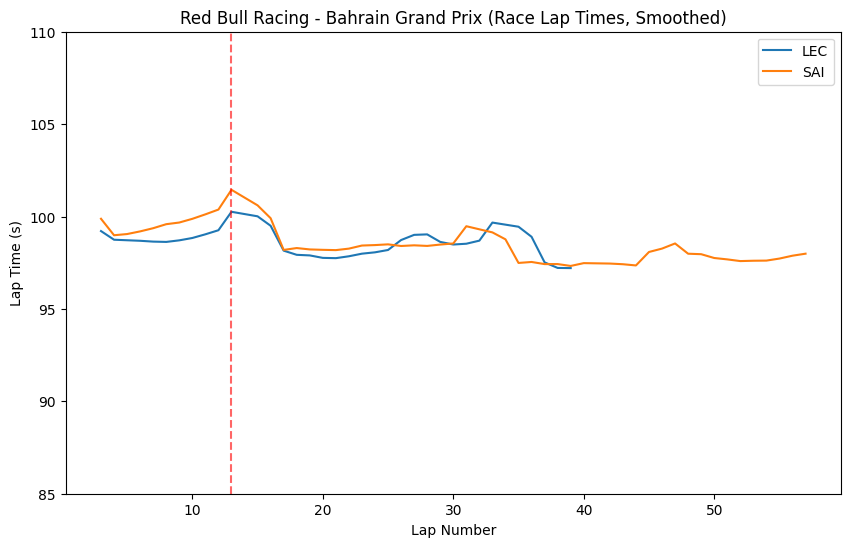

In [16]:
import matplotlib.pyplot as plt

# Filter for Bahrain GP and Race session
gp_data = df_2023[(df_2023["GP"] == "Bahrain Grand Prix") & 
                  (df_2023["Session"] == "R")]

# Filter Red Bull team
team_data = gp_data[gp_data["Team"] == "Ferrari"]

plt.figure(figsize=(10,6))

for driver in team_data["Driver"].unique():
    driver_data = team_data[team_data["Driver"] == driver].copy()

    # Remove pit stops / outliers (laps > 110 sec)
    driver_data = driver_data[driver_data["LapTime"] < 110]

    # Add smoothing (rolling average of 3 laps)
    driver_data["LapTime_smooth"] = driver_data["LapTime"].rolling(3).mean()

    plt.plot(driver_data["LapNumber"], driver_data["LapTime_smooth"], label=driver)

for lap in driver_data[driver_data["LapTime"] > 102]["LapNumber"]:
    plt.axvline(x=lap, color="red", linestyle="--", alpha=0.6)

plt.title("Red Bull Racing - Bahrain Grand Prix (Race Lap Times, Smoothed)")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (s)")
plt.ylim(85, 110)   # Focus on the real lap times
plt.legend()
plt.show()


In [12]:
df_2023['Team'].unique()

array(['Williams', 'Aston Martin', 'Alfa Romeo', 'AlphaTauri', 'Alpine',
       'Mercedes', 'Haas F1 Team', 'Ferrari', 'McLaren',
       'Red Bull Racing'], dtype=object)

In [1]:
import pandas as pd 
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)


C:\Users\VANSH\AppData\Local\Temp\ipykernel_10560\3308986149.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [4]:
df_2023.columns

Index(['Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound', 'TyreLife',
       'FreshTyre', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Team', 'Position', 'DriverTime', 'WeatherTime', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
       'RoundNumber', 'Session', 'Date', 'GP'],
      dtype='object')

In [2]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_5792\789486041.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [3]:
df_2023[['Driver','GP','Session','Stint','Compound','LapNumber','TyreLife']].head(10)

,Driver,GP,Session,Stint,Compound,LapNumber,TyreLife
0,ALB,Bahrain Grand Prix,FP1,2,MEDIUM,3,3
1,ALB,Bahrain Grand Prix,FP1,2,MEDIUM,4,4
2,ALB,Bahrain Grand Prix,FP1,2,MEDIUM,5,5
3,ALB,Bahrain Grand Prix,FP1,2,MEDIUM,6,6
4,ALB,Bahrain Grand Prix,FP1,3,MEDIUM,8,8
5,ALB,Bahrain Grand Prix,FP1,3,MEDIUM,9,9
6,ALB,Bahrain Grand Prix,FP1,4,MEDIUM,11,2
7,ALB,Bahrain Grand Prix,FP1,4,MEDIUM,13,4
8,ALB,Bahrain Grand Prix,FP1,4,MEDIUM,14,5
9,ALO,Bahrain Grand Prix,FP1,1,MEDIUM,2,2


In [10]:
race_data = df_2023[(df_2023['Session'] == 'R') & (df_2023['Driver'] == "VER") & (df_2023['GP'] == "Bahrain Grand Prix")]
race_data

,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
1963,VER,1,1,1,SOFT,4,0,99.019,NaN,42.414,...,22.0,1016.7,False,31.2,190.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1964,VER,1,2,1,SOFT,5,0,97.974,31.342,42.504,...,22.0,1016.9,False,31.1,197.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1966,VER,1,3,1,SOFT,6,0,98.006,31.388,42.469,...,22.0,1016.7,False,31.2,170.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1968,VER,1,4,1,SOFT,7,0,97.976,31.271,42.642,...,22.0,1016.9,False,31.1,236.0,0.8,1.0,R,05-03-2023,Bahrain Grand Prix
1969,VER,1,5,1,SOFT,8,0,98.035,31.244,42.724,...,22.0,1016.9,False,31.0,225.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1971,VER,1,6,1,SOFT,9,0,97.986,31.341,42.632,...,22.0,1016.9,False,31.0,175.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1972,VER,1,7,1,SOFT,10,0,98.021,31.290,42.763,...,21.0,1016.9,False,30.9,197.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1974,VER,1,8,1,SOFT,11,0,98.154,31.291,42.833,...,21.0,1016.9,False,30.9,173.0,1.0,1.0,R,05-03-2023,Bahrain Grand Prix
1976,VER,1,9,1,SOFT,12,0,98.278,31.336,42.823,...,21.0,1016.9,False,30.8,193.0,0.6,1.0,R,05-03-2023,Bahrain Grand Prix
1977,VER,1,10,1,SOFT,13,0,98.369,31.361,42.884,...,21.0,1016.9,False,30.8,195.0,0.8,1.0,R,05-03-2023,Bahrain Grand Prix


In [13]:
df_2023

,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39872,ZHO,24,54,3,MEDIUM,17,1,90.289,18.143,38.926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abu Dhabi Grand Prix
39873,ZHO,24,55,3,MEDIUM,18,1,90.416,18.206,38.783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abu Dhabi Grand Prix
39874,ZHO,24,56,3,MEDIUM,19,1,90.200,18.057,38.998,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abu Dhabi Grand Prix
39875,ZHO,24,57,3,MEDIUM,20,1,90.991,17.939,38.767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abu Dhabi Grand Prix


In [14]:
stints = race_data.groupby(['GP','Driver','Stint','Compound'])['TyreLife'].max().reset_index()
stints.head(10)

,GP,Driver,Stint,Compound,TyreLife
0,Bahrain Grand Prix,VER,1,SOFT,17
1,Bahrain Grand Prix,VER,2,SOFT,22
2,Bahrain Grand Prix,VER,3,HARD,21


In [18]:
stints = stints.rename(columns={'TyreLife': 'StintLength'})

0        MEDIUM
1        MEDIUM
2        MEDIUM
3        MEDIUM
4        MEDIUM
          ...  
39872    MEDIUM
39873    MEDIUM
39874    MEDIUM
39875    MEDIUM
39876    MEDIUM
Name: Compound, Length: 39877, dtype: object

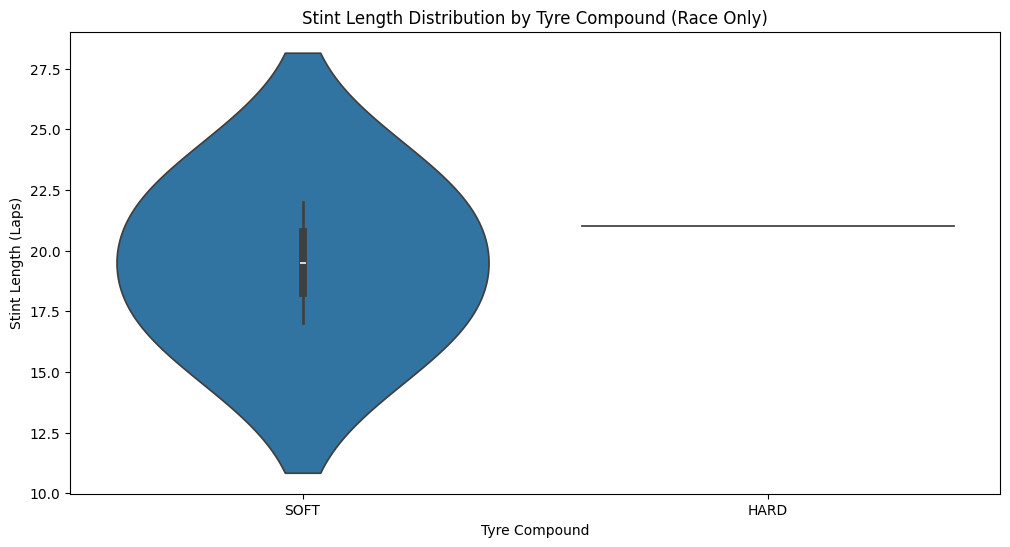

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.violinplot(
data = stints,
x = 'Compound',
y = 'StintLength'
)
plt.title("Stint Length Distribution by Tyre Compound (Race Only)")
plt.xlabel('Tyre Compound')
plt.ylabel('Stint Length (Laps)')
plt.show()

In [19]:
df_2023['GP'].unique()


array(['Bahrain Grand Prix', 'Saudi Arabian Grand Prix',
       'Australian Grand Prix', 'Azerbaijan Grand Prix',
       'Miami Grand Prix', 'Monaco Grand Prix', 'Spanish Grand Prix',
       'Canadian Grand Prix', 'Austrian Grand Prix', 'British Grand Prix',
       'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix',
       'Italian Grand Prix', 'Singapore Grand Prix',
       'Japanese Grand Prix', 'Qatar Grand Prix',
       'United States Grand Prix', 'Mexico City Grand Prix',
       'São Paulo Grand Prix', 'Las Vegas Grand Prix',
       'Abu Dhabi Grand Prix'], dtype=object)

In [27]:
df_2023.columns

Index(['Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound', 'TyreLife',
       'FreshTyre', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Team', 'Position', 'DriverTime', 'WeatherTime', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
       'RoundNumber', 'Session', 'Date', 'GP'],
      dtype='object')

In [26]:
race_data = df_2023[df_2023['Session'].isin(['R'])]
race_data['Driver'].nunique(), race_data['GP'].nunique()


(22, 21)

In [29]:
race_data = df_2023[df_2023['Session'].isin(['R'])]

stints = (
race_data
.groupby(['GP', 'Driver', 'Stint', 'Compound'])['TyreLife']
.max()
.reset_index()
.rename(columns={'TyreLife': 'StintLength'})
)

print(stints.shape)
print(stints.head(10))

(1198, 5)
                      GP Driver  Stint Compound  StintLength
0  Australian Grand Prix    ALB      1   MEDIUM            6
1  Australian Grand Prix    ALO      1   MEDIUM            8
2  Australian Grand Prix    ALO      2     HARD           46
3  Australian Grand Prix    BOT      1     SOFT            1
4  Australian Grand Prix    BOT      2     HARD            6
5  Australian Grand Prix    BOT      3     HARD           52
6  Australian Grand Prix    DEV      1     HARD            7
7  Australian Grand Prix    DEV      2   MEDIUM           37
8  Australian Grand Prix    DEV      3     SOFT            8
9  Australian Grand Prix    GAS      1     SOFT            7


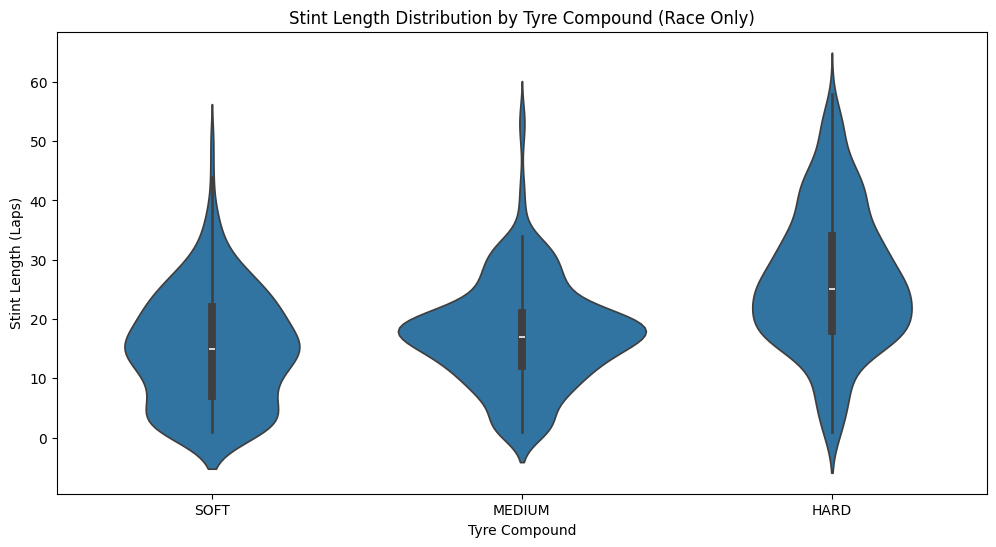

In [31]:
compound_order = ['SOFT', 'MEDIUM', 'HARD']
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.violinplot(
data = stints,
x = 'Compound',
y = 'StintLength',
order= compound_order,
inner = 'box'
)
plt.title("Stint Length Distribution by Tyre Compound (Race Only)")
plt.xlabel('Tyre Compound')
plt.ylabel('Stint Length (Laps)')
plt.show()

In [1]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_29420\789486041.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [3]:
gp_order = [
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
    "Australian Grand Prix",
    "Azerbaijan Grand Prix",
    "Miami Grand Prix",
    "Monaco Grand Prix",
    "Spanish Grand Prix",
    "Canadian Grand Prix",
    "Austrian Grand Prix",
    "British Grand Prix",
    "Hungarian Grand Prix",
    "Belgian Grand Prix",
    "Dutch Grand Prix",
    "Italian Grand Prix",
    "Singapore Grand Prix",
    "Japanese Grand Prix",
    "Qatar Grand Prix",
    "United States Grand Prix",
    "Mexico City Grand Prix",
    "São Paulo Grand Prix",
    "Las Vegas Grand Prix",
    "Abu Dhabi Grand Prix"
]


In [5]:
race_data = df_2023[df_2023['Session'].isin(['R'])]

stints = (
race_data
.groupby(['GP', 'Driver', 'Stint', 'Compound'])['TyreLife']
.max()
.reset_index()
.rename(columns={'TyreLife': 'StintLength'})
)

print(stints.shape)
print(stints.head(10))

(1198, 5)
                      GP Driver  Stint Compound  StintLength
0  Australian Grand Prix    ALB      1   MEDIUM            6
1  Australian Grand Prix    ALO      1   MEDIUM            8
2  Australian Grand Prix    ALO      2     HARD           46
3  Australian Grand Prix    BOT      1     SOFT            1
4  Australian Grand Prix    BOT      2     HARD            6
5  Australian Grand Prix    BOT      3     HARD           52
6  Australian Grand Prix    DEV      1     HARD            7
7  Australian Grand Prix    DEV      2   MEDIUM           37
8  Australian Grand Prix    DEV      3     SOFT            8
9  Australian Grand Prix    GAS      1     SOFT            7


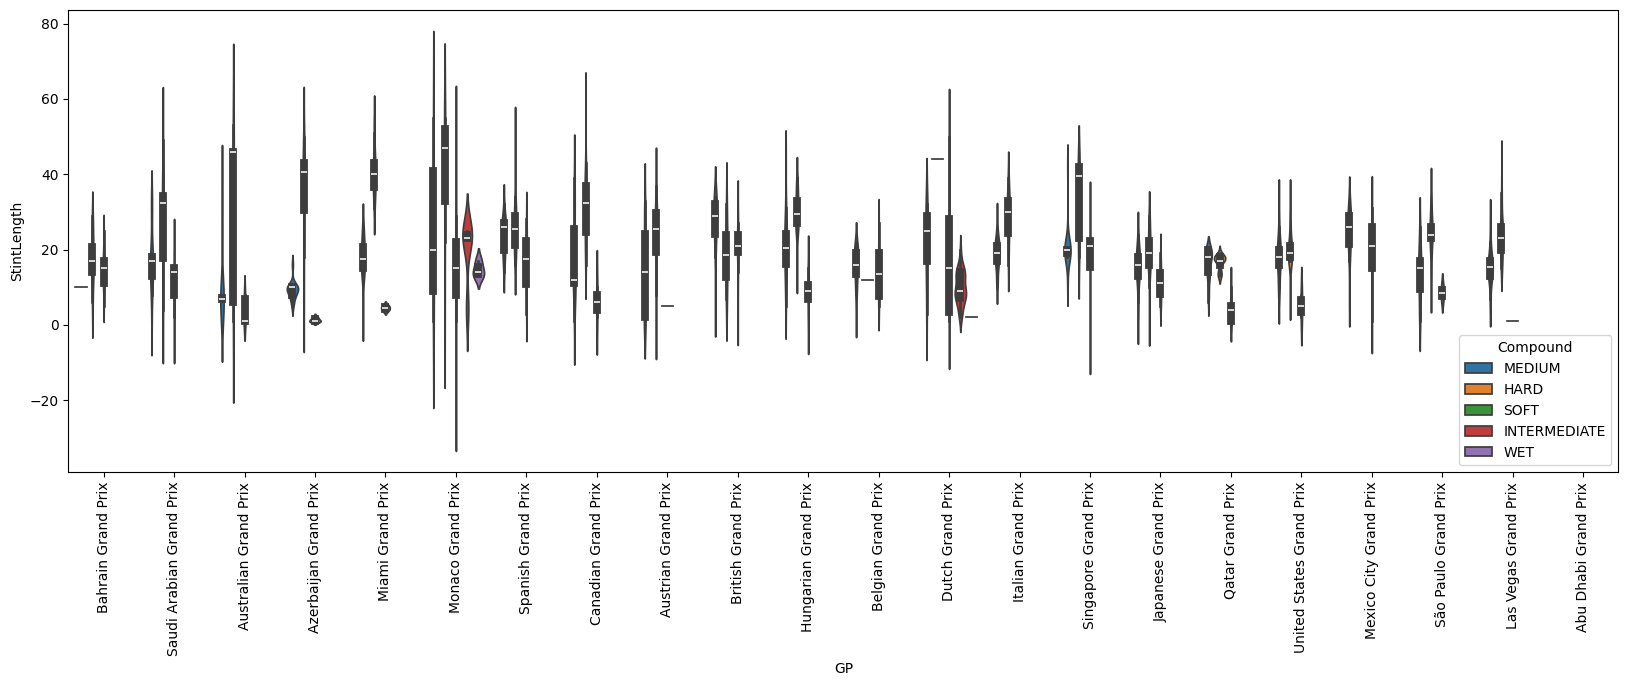

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,6))
sns.violinplot(
data= stints,
x = 'GP',
y = 'StintLength',
hue = 'Compound',
order = gp_order,
split = False
)

plt.xticks(rotation=90)
plt.show()

In [7]:
stints.shape

(1198, 5)

#### Pre-Plot Preparation

In [4]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)
race_data = df_2023[df_2023['Session'].isin(['R'])]

stints = (
race_data
.groupby(['GP', 'Driver', 'Stint', 'Compound'])['TyreLife']
.max()
.reset_index()
.rename(columns={'TyreLife': 'StintLength'})
)

print(stints.shape)
print(stints.head(10))
#1: Setting the compound order
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

#2: Removing the Nan values
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

#3: Set Compound as categorical
stints_clean['Compound'] = pd.Categorical(
stints_clean['Compound'],
categories = compound_order,
ordered = True
)

#4: Compute global y-axis limits for all the batches
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# add a visual buffer
y_lower = max(0, y_min-2)
y_upper = y_max + 2

# -------------------------------
# Phase 1: Pre-plot preparation
# -------------------------------

# 1. Define compound order (explicit, consistent everywhere)
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

# 2. Keep only valid compounds (drop NaNs or weird entries)
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

# 3. Set Compound as ordered categorical
stints_clean['Compound'] = pd.Categorical(
    stints_clean['Compound'],
    categories=compound_order,
    ordered=True
)

# 4. Compute global y-axis limits (same for all batches)
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# Add small visual buffer
y_lower = max(0, y_min - 2)
y_upper = y_max + 2

print("✅ Phase 1 complete")
print(f"Compound order: {compound_order}")
print(f"Global y-limits: ({y_lower}, {y_upper})")
print(f"Total stints used: {stints_clean.shape[0]}")


(1198, 5)
                      GP Driver  Stint Compound  StintLength
0  Australian Grand Prix    ALB      1   MEDIUM            6
1  Australian Grand Prix    ALO      1   MEDIUM            8
2  Australian Grand Prix    ALO      2     HARD           46
3  Australian Grand Prix    BOT      1     SOFT            1
4  Australian Grand Prix    BOT      2     HARD            6
5  Australian Grand Prix    BOT      3     HARD           52
6  Australian Grand Prix    DEV      1     HARD            7
7  Australian Grand Prix    DEV      2   MEDIUM           37
8  Australian Grand Prix    DEV      3     SOFT            8
9  Australian Grand Prix    GAS      1     SOFT            7
✅ Phase 1 complete
Compound order: ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
Global y-limits: (0, 60)
Total stints used: 1198


C:\Users\VANSH\AppData\Local\Temp\ipykernel_24288\3868459930.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


#### Phase 2: Batch 1 Plot

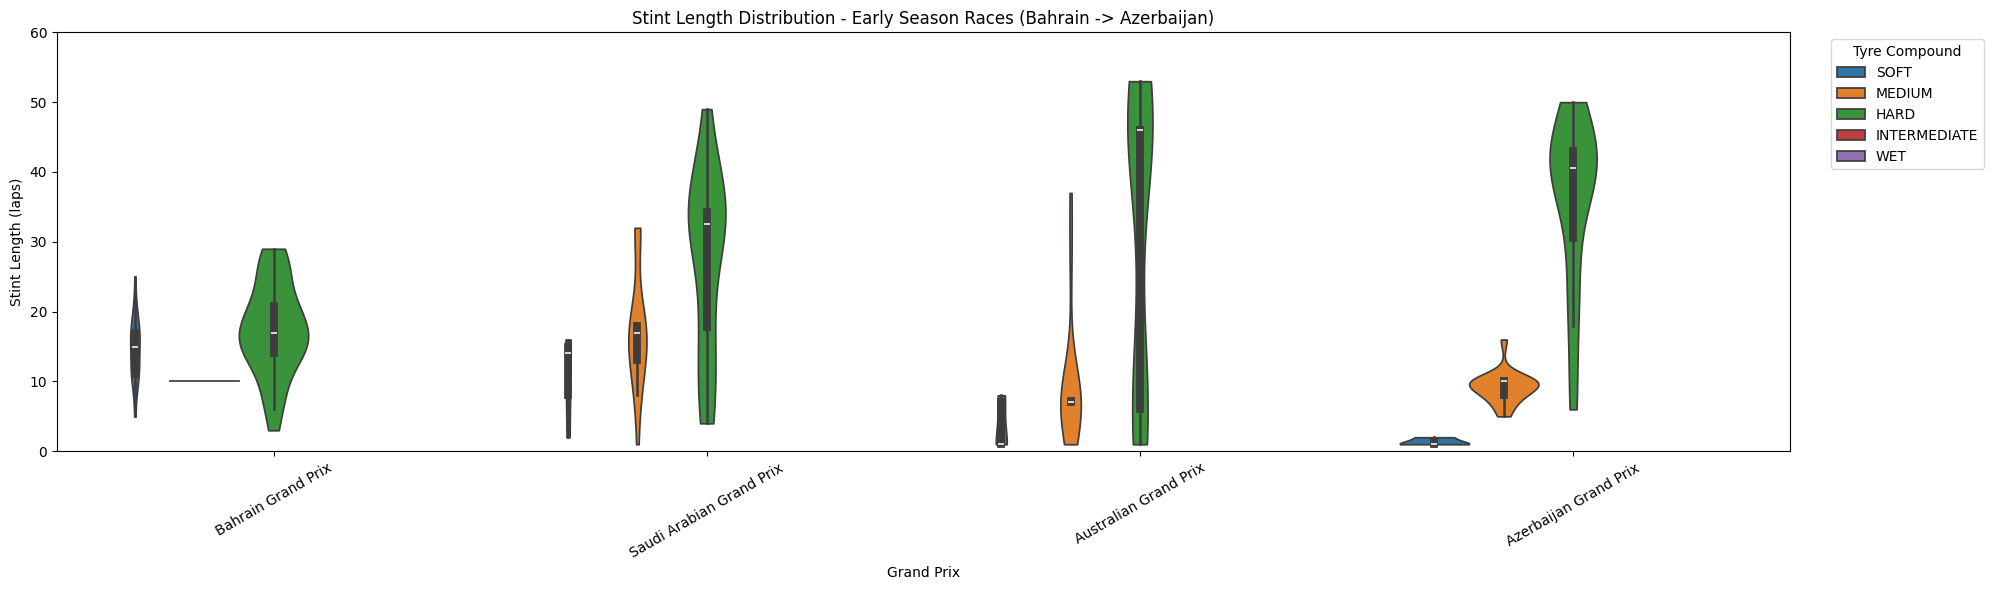

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns 

batch1_gp = ["Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
    "Australian Grand Prix",
    "Azerbaijan Grand Prix"]

# Filter data for Batch 1
batch1_data = stints_clean[stints_clean['GP'].isin(batch1_gp)].copy()

#plot
plt.figure(figsize=(20,6))
sns.violinplot(
data = batch1_data,
x = 'GP',
y = 'StintLength',
hue = 'Compound',
order = batch1_gp,
hue_order = compound_order,
inner = 'box',
cut = 0
)

#Formatting
plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel('Grand Prix')
plt.ylabel('Stint Length (laps)')
plt.title('Stint Length Distribution - Early Season Races (Bahrain -> Azerbaijan)')

plt.legend(title = "Tyre Compound", bbox_to_anchor=(1.02, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

#### Batch 2 Plotting

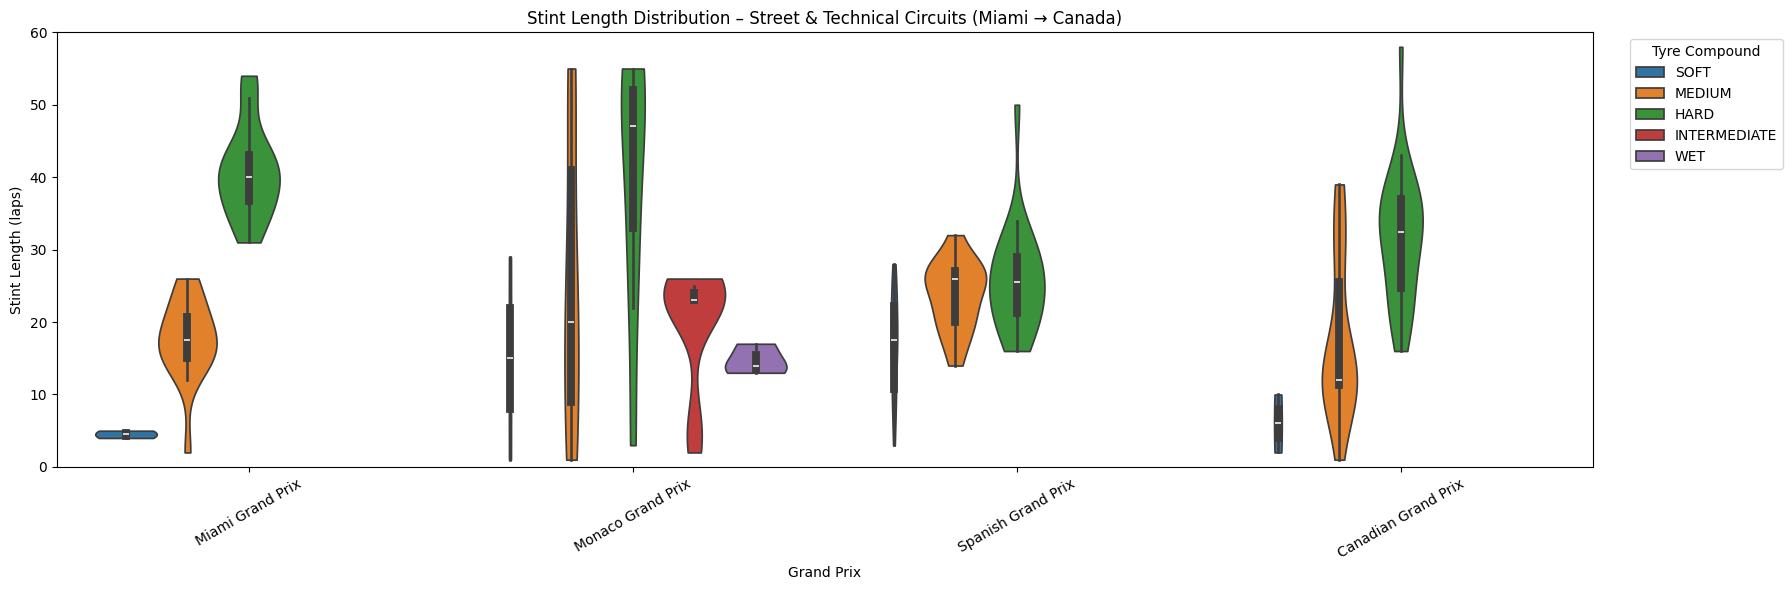

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns 
batch2_gps = [
    "Miami Grand Prix",
    "Monaco Grand Prix",
    "Spanish Grand Prix",
    "Canadian Grand Prix"
]
batch2_data = stints_clean[stints_clean['GP'].isin(batch2_gps)].copy()

plt.figure(figsize=(18, 6))
sns.violinplot(
    data=batch2_data,
    x='GP',
    y='StintLength',
    hue='Compound',
    order=batch2_gps,
    hue_order=compound_order,
    inner='box',
    cut=0
)

# Formatting
plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel("Grand Prix")
plt.ylabel("Stint Length (laps)")
plt.title("Stint Length Distribution – Street & Technical Circuits (Miami → Canada)")

plt.legend(title="Tyre Compound", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Batch 3 Plotting

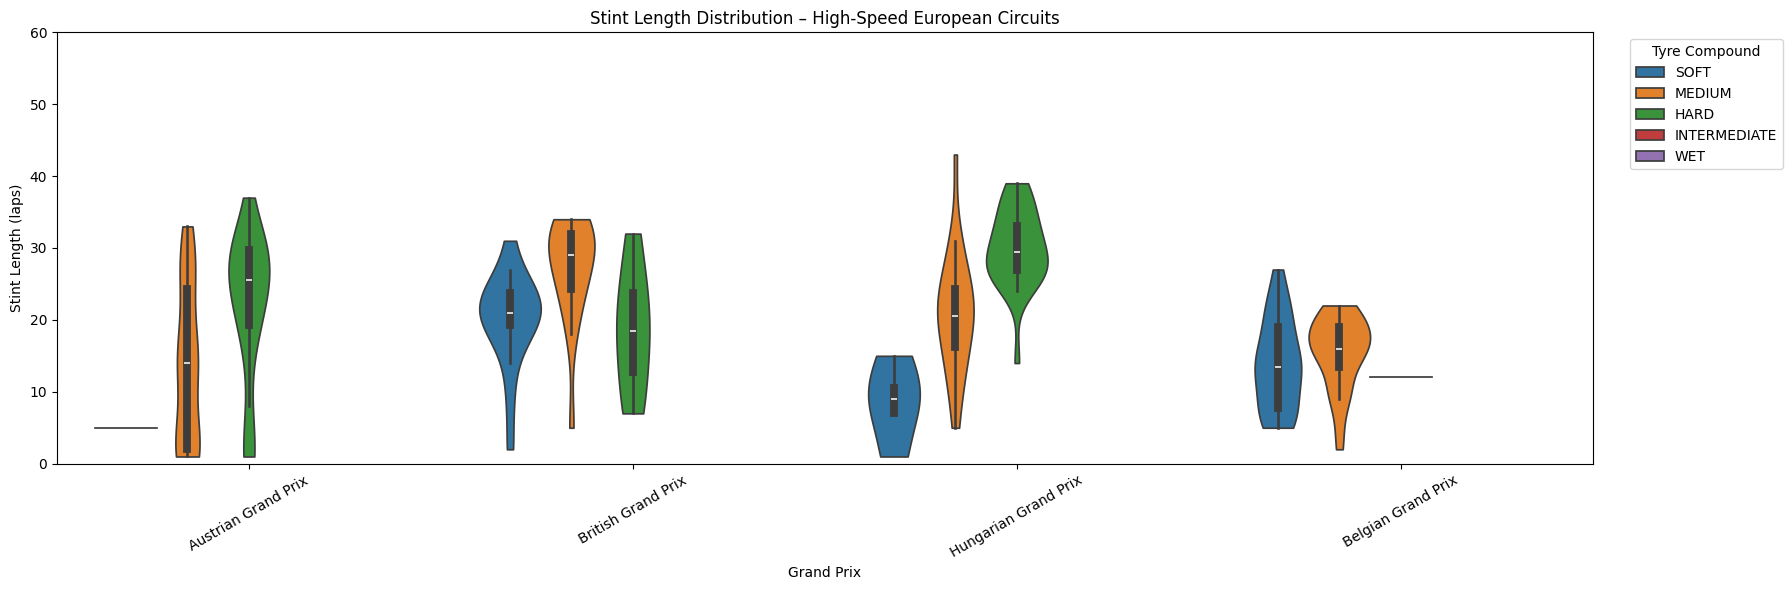

In [7]:
# -------------------------------
# Phase 2: Batch 3 plotting
# -------------------------------

batch3_gps = [
    "Austrian Grand Prix",
    "British Grand Prix",
    "Hungarian Grand Prix",
    "Belgian Grand Prix"
]

# Filter data for Batch 3
batch3_data = stints_clean[stints_clean['GP'].isin(batch3_gps)].copy()

# Plot
plt.figure(figsize=(18, 6))
sns.violinplot(
    data=batch3_data,
    x='GP',
    y='StintLength',
    hue='Compound',
    order=batch3_gps,
    hue_order=compound_order,
    inner='box',
    cut=0
)

# Formatting
plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel("Grand Prix")
plt.ylabel("Stint Length (laps)")
plt.title("Stint Length Distribution – High-Speed European Circuits")

plt.legend(title="Tyre Compound", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Batch 4

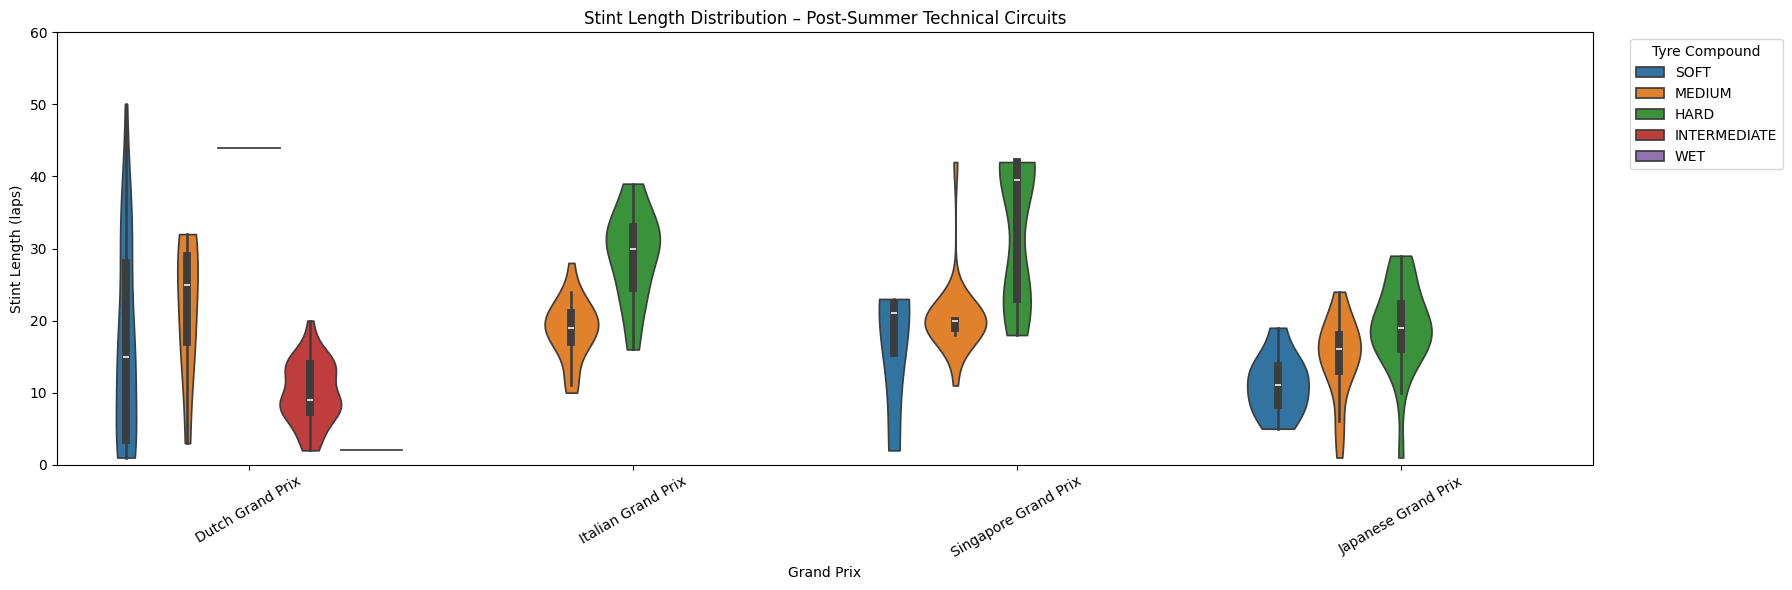

In [8]:
# -------------------------------
# Phase 2: Batch 4 plotting
# -------------------------------

batch4_gps = [
    "Dutch Grand Prix",
    "Italian Grand Prix",
    "Singapore Grand Prix",
    "Japanese Grand Prix"
]

batch4_data = stints_clean[stints_clean['GP'].isin(batch4_gps)].copy()

plt.figure(figsize=(18, 6))
sns.violinplot(
    data=batch4_data,
    x='GP',
    y='StintLength',
    hue='Compound',
    order=batch4_gps,
    hue_order=compound_order,
    inner='box',
    cut=0
)

plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel("Grand Prix")
plt.ylabel("Stint Length (laps)")
plt.title("Stint Length Distribution – Post-Summer Technical Circuits")

plt.legend(title="Tyre Compound", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Batch 5

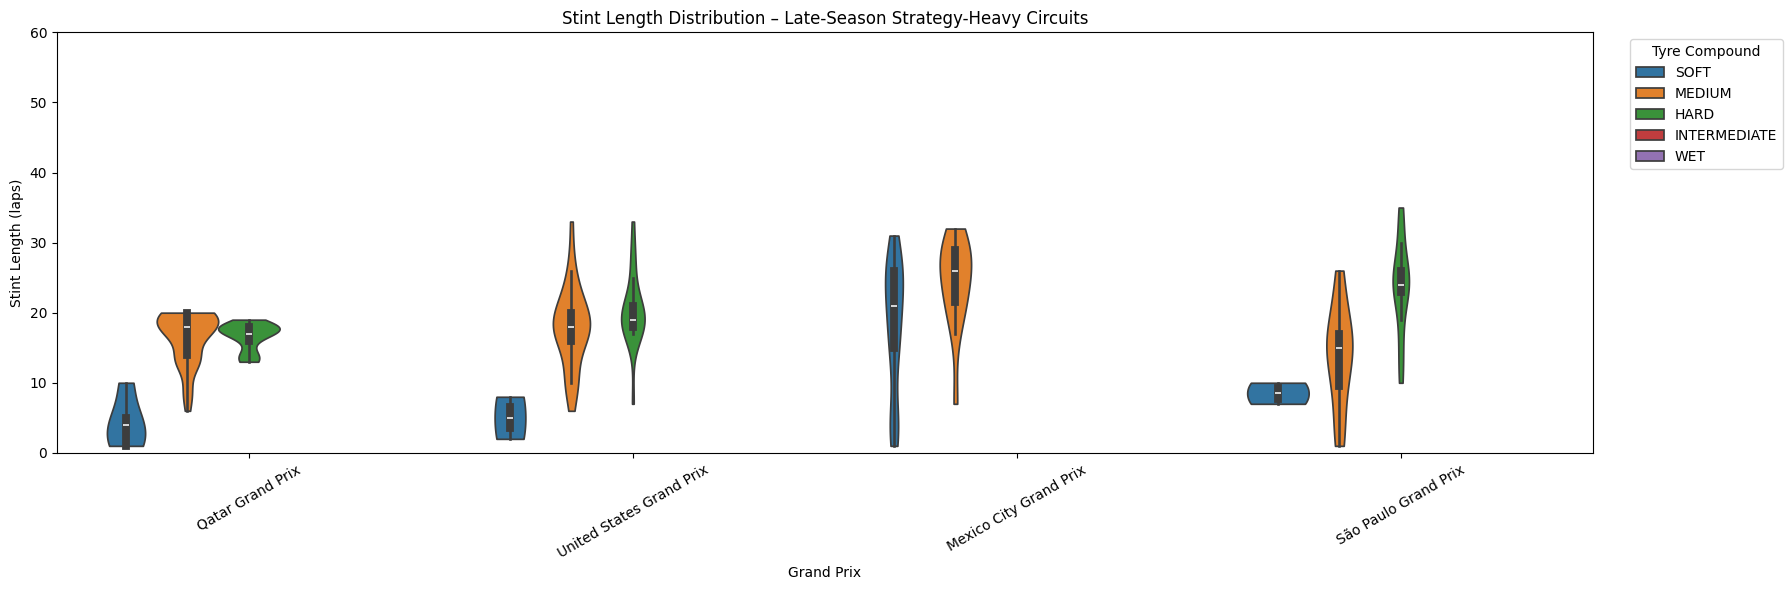

In [9]:
# -------------------------------
# Phase 2: Batch 5 plotting
# -------------------------------

batch5_gps = [
    "Qatar Grand Prix",
    "United States Grand Prix",
    "Mexico City Grand Prix",
    "São Paulo Grand Prix"
]

batch5_data = stints_clean[stints_clean['GP'].isin(batch5_gps)].copy()

plt.figure(figsize=(18, 6))
sns.violinplot(
    data=batch5_data,
    x='GP',
    y='StintLength',
    hue='Compound',
    order=batch5_gps,
    hue_order=compound_order,
    inner='box',
    cut=0
)

plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel("Grand Prix")
plt.ylabel("Stint Length (laps)")
plt.title("Stint Length Distribution – Late-Season Strategy-Heavy Circuits")

plt.legend(title="Tyre Compound", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Batch 6

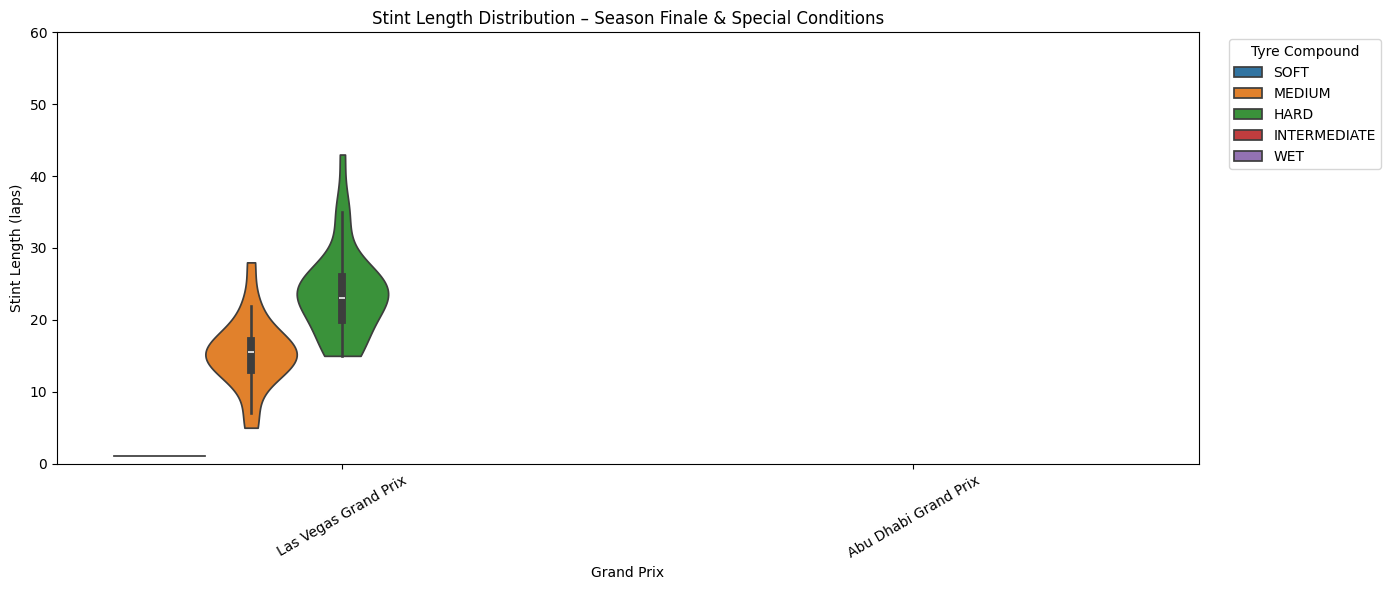

In [10]:
# -------------------------------
# Phase 2: Batch 6 plotting
# -------------------------------

batch6_gps = [
    "Las Vegas Grand Prix",
    "Abu Dhabi Grand Prix"
]

batch6_data = stints_clean[stints_clean['GP'].isin(batch6_gps)].copy()

plt.figure(figsize=(14, 6))
sns.violinplot(
    data=batch6_data,
    x='GP',
    y='StintLength',
    hue='Compound',
    order=batch6_gps,
    hue_order=compound_order,
    inner='box',
    cut=0
)

plt.ylim(y_lower, y_upper)
plt.xticks(rotation=30)
plt.xlabel("Grand Prix")
plt.ylabel("Stint Length (laps)")
plt.title("Stint Length Distribution – Season Finale & Special Conditions")

plt.legend(title="Tyre Compound", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Abu Dhabi GP Stint Analysis

In [11]:
df_2023.loc[
    (df_2023['GP'] == 'Abu Dhabi Grand Prix') & (df_2023['Session'].isna()),
    'Session'
] = 'R'


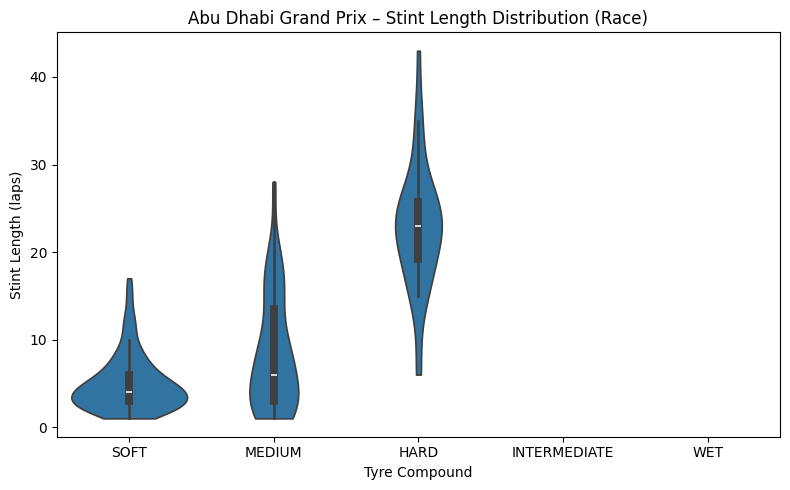

In [12]:
# ==============================
# Abu Dhabi GP – Isolated Fix & Plot
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Minimal Abu Dhabi session fix (ONLY this GP) ----
df_2023.loc[
    (df_2023['GP'] == 'Abu Dhabi Grand Prix') & (df_2023['Session'].isna()),
    'Session'
] = 'R'

# ---- 2. Filter Abu Dhabi race data only ----
abu_race = df_2023[
    (df_2023['GP'] == 'Abu Dhabi Grand Prix') &
    (df_2023['Session'] == 'R')
].copy()

# ---- 3. Build stints for Abu Dhabi ----
abu_stints = (
    abu_race
    .groupby(['GP', 'Driver', 'Stint', 'Compound'])
    .agg(StintLength=('LapNumber', 'count'))
    .reset_index()
)

# Normalize compound names
abu_stints['Compound'] = abu_stints['Compound'].str.upper()

# Keep valid compounds only
compound_order = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
abu_stints = abu_stints[abu_stints['Compound'].isin(compound_order)]

# ---- 4. Plot Abu Dhabi only ----
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=abu_stints,
    x='Compound',
    y='StintLength',
    order=compound_order,
    inner='box',
    cut=0
)

plt.title("Abu Dhabi Grand Prix – Stint Length Distribution (Race)")
plt.xlabel("Tyre Compound")
plt.ylabel("Stint Length (laps)")
plt.tight_layout()
plt.show()


In [1]:


import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_18196\2228221105.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [5]:
stints_clean[(stints_clean['Driver'] == 'PER') & (stints_clean['GP'] == 'Australian Grand Prix')]

,GP,Driver,Stint,Compound,StintLength
22,Australian Grand Prix,PER,1,HARD,1
23,Australian Grand Prix,PER,2,MEDIUM,1
24,Australian Grand Prix,PER,3,HARD,5
25,Australian Grand Prix,PER,4,HARD,47


### EDA_2: Stints per race (2023)

In [6]:
#Step1: group by GP and Driver to see how many stints each driver had in each GP
grouped = stints_clean.groupby(['GP', 'Driver'])

#Step2: Count stints per driver per GP
stint_counts = grouped.size()

#Step3: Convert to clean dataframe
stints_per_driver = stint_counts.reset_index(name='StintCount')

In [7]:
stints_per_driver.head(20)

,GP,Driver,StintCount
0,Australian Grand Prix,ALB,1
1,Australian Grand Prix,ALO,2
2,Australian Grand Prix,BOT,3
3,Australian Grand Prix,DEV,3
4,Australian Grand Prix,GAS,2
5,Australian Grand Prix,HAM,2
6,Australian Grand Prix,HUL,2
7,Australian Grand Prix,MAG,2
8,Australian Grand Prix,NOR,2
9,Australian Grand Prix,OCO,3


In [35]:
stints_per_driver[stints_per_driver['GP'] == 'Australian Grand Prix']

,GP,Driver,StintCount
0,Australian Grand Prix,ALB,1
1,Australian Grand Prix,ALO,2
2,Australian Grand Prix,BOT,3
3,Australian Grand Prix,DEV,3
4,Australian Grand Prix,GAS,2
5,Australian Grand Prix,HAM,2
6,Australian Grand Prix,HUL,2
7,Australian Grand Prix,MAG,2
8,Australian Grand Prix,NOR,2
9,Australian Grand Prix,OCO,3


In [1]:


import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_24288\2228221105.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [8]:
stints_per_driver['GP'].unique()

array(['Australian Grand Prix', 'Austrian Grand Prix',
       'Azerbaijan Grand Prix', 'Bahrain Grand Prix',
       'Belgian Grand Prix', 'British Grand Prix', 'Canadian Grand Prix',
       'Dutch Grand Prix', 'Hungarian Grand Prix', 'Italian Grand Prix',
       'Japanese Grand Prix', 'Las Vegas Grand Prix',
       'Mexico City Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix',
       'Qatar Grand Prix', 'Saudi Arabian Grand Prix',
       'Singapore Grand Prix', 'Spanish Grand Prix',
       'São Paulo Grand Prix', 'United States Grand Prix'], dtype=object)

In [9]:
stints_per_driver[stints_per_driver['GP'] == 'Spanish Grand Prix']['StintCount'].unique()
stints_per_driver[stints_per_driver['GP'] == 'Italian Grand Prix']['StintCount'].unique()
stints_per_driver[stints_per_driver['GP'] == 'Belgian Grand Prix']['StintCount'].unique()



array([4, 3, 2], dtype=int64)

In [10]:
# Count of drivers per stint count for Spanish Grand Prix
stints_per_driver[stints_per_driver['GP'] == 'Spanish Grand Prix']['StintCount'].value_counts().sort_index()

# Alternative using groupby:
# stints_per_driver[stints_per_driver['GP'] == 'Spanish Grand Prix'].groupby('StintCount')['Driver'].count()


StintCount
3    17
4     3
Name: count, dtype: int64

In [33]:
stints_per_driver[stints_per_driver['GP'] == 'Italian Grand Prix']['StintCount'].value_counts().sort_index()

StintCount
2    13
3     6
Name: count, dtype: int64

##### Dominant stint length

In [11]:
# to count how many drivers used each stint_count per GP
gp_stint_count = (
    stints_per_driver
    .groupby(['GP', 'StintCount'])
    .size()
    .reset_index(name='DriverCount')
)
gp_stint_count.head(7)

,GP,StintCount,DriverCount
0,Australian Grand Prix,1,1
1,Australian Grand Prix,2,12
2,Australian Grand Prix,3,4
3,Australian Grand Prix,4,1
4,Australian Grand Prix,5,1
5,Austrian Grand Prix,3,1
6,Austrian Grand Prix,4,15


In [12]:
# step 2: sorting in descending order by DriverCount within each GP
gp_stint_count = gp_stint_count.sort_values(by=['GP', 'DriverCount'], ascending=[True, False])
gp_stint_count.head(10)

,GP,StintCount,DriverCount
1,Australian Grand Prix,2,12
2,Australian Grand Prix,3,4
0,Australian Grand Prix,1,1
3,Australian Grand Prix,4,1
4,Australian Grand Prix,5,1
6,Austrian Grand Prix,4,15
7,Austrian Grand Prix,5,4
5,Austrian Grand Prix,3,1
9,Azerbaijan Grand Prix,2,16
10,Azerbaijan Grand Prix,3,2


In [14]:
dominant_stint_count = gp_stint_count.drop_duplicates(subset=['GP'])
dominant_stint_count.head(10)

,GP,StintCount,DriverCount
1,Australian Grand Prix,2,12
6,Austrian Grand Prix,4,15
9,Azerbaijan Grand Prix,2,16
13,Bahrain Grand Prix,3,10
17,Belgian Grand Prix,3,12
20,British Grand Prix,2,13
25,Canadian Grand Prix,3,13
30,Dutch Grand Prix,6,9
33,Hungarian Grand Prix,3,18
34,Italian Grand Prix,2,13


##### Adding confidence 

In [15]:
# total drivers per GP
total_drivers_per_gp = stints_per_driver.groupby('GP')['Driver'].size().reset_index(name='TotalDrivers')

# remove old total-driver columns (if cell was run before), then merge cleanly
dominant_stint_count = dominant_stint_count.drop(
	columns=['TotalDrivers', 'TotalDrivers_x', 'TotalDrivers_y'],
	errors='ignore'
)
dominant_stint_count = dominant_stint_count.merge(total_drivers_per_gp, on='GP', how='left')

# compute confidence as percentage of drivers using the dominant stint count
dominant_stint_count['Confidence'] = (
	dominant_stint_count['DriverCount'] / dominant_stint_count['TotalDrivers']
) * 100

dominant_stint_count.head(10)

,GP,StintCount,DriverCount,TotalDrivers,Confidence
0,Australian Grand Prix,2,12,19,63.157895
1,Austrian Grand Prix,4,15,20,75.000000
2,Azerbaijan Grand Prix,2,16,20,80.000000
3,Bahrain Grand Prix,3,10,20,50.000000
4,Belgian Grand Prix,3,12,19,63.157895
5,British Grand Prix,2,13,20,65.000000
6,Canadian Grand Prix,3,13,20,65.000000
7,Dutch Grand Prix,6,9,20,45.000000
8,Hungarian Grand Prix,3,18,20,90.000000
9,Italian Grand Prix,2,13,19,68.421053


In [1]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_22004\789486041.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [7]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)
race_data = df_2023[df_2023['Session'].isin(['R'])]

stints = (
race_data
.groupby(['GP', 'Driver', 'Stint', 'Compound'])['TyreLife']
.max()
.reset_index()
.rename(columns={'TyreLife': 'StintLength'})
)

print(stints.shape)
print(stints.head(10))
#1: Setting the compound order
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

#2: Removing the Nan values
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

#3: Set Compound as categorical
stints_clean['Compound'] = pd.Categorical(
stints_clean['Compound'],
categories = compound_order,
ordered = True
)

#4: Compute global y-axis limits for all the batches
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# add a visual buffer
y_lower = max(0, y_min-2)
y_upper = y_max + 2

# -------------------------------
# Phase 1: Pre-plot preparation
# -------------------------------

# 1. Define compound order (explicit, consistent everywhere)
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

# 2. Keep only valid compounds (drop NaNs or weird entries)
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

# 3. Set Compound as ordered categorical
stints_clean['Compound'] = pd.Categorical(
    stints_clean['Compound'],
    categories=compound_order,
    ordered=True
)

# 4. Compute global y-axis limits (same for all batches)
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# Add small visual buffer
y_lower = max(0, y_min - 2)
y_upper = y_max + 2

print("✅ Phase 1 complete")
print(f"Compound order: {compound_order}")
print(f"Global y-limits: ({y_lower}, {y_upper})")
print(f"Total stints used: {stints_clean.shape[0]}")


(1198, 5)
                      GP Driver  Stint Compound  StintLength
0  Australian Grand Prix    ALB      1   MEDIUM            6
1  Australian Grand Prix    ALO      1   MEDIUM            8
2  Australian Grand Prix    ALO      2     HARD           46
3  Australian Grand Prix    BOT      1     SOFT            1
4  Australian Grand Prix    BOT      2     HARD            6
5  Australian Grand Prix    BOT      3     HARD           52
6  Australian Grand Prix    DEV      1     HARD            7
7  Australian Grand Prix    DEV      2   MEDIUM           37
8  Australian Grand Prix    DEV      3     SOFT            8
9  Australian Grand Prix    GAS      1     SOFT            7
✅ Phase 1 complete
Compound order: ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
Global y-limits: (0, 60)
Total stints used: 1198


C:\Users\VANSH\AppData\Local\Temp\ipykernel_22004\3868459930.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


In [1]:


import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_19092\2228221105.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


### Feature_Engineering_1

In [2]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("final_merged_2023_data.csv")
df_2023.head(5)
race_data = df_2023[df_2023['Session'].isin(['R'])]

stints = (
race_data
.groupby(['GP', 'Driver', 'Stint', 'Compound'])['TyreLife']
.max()
.reset_index()
.rename(columns={'TyreLife': 'StintLength'})
)

print(stints.shape)
print(stints.head(10))
#1: Setting the compound order
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

#2: Removing the Nan values
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

#3: Set Compound as categorical
stints_clean['Compound'] = pd.Categorical(
stints_clean['Compound'],
categories = compound_order,
ordered = True
)

#4: Compute global y-axis limits for all the batches
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# add a visual buffer
y_lower = max(0, y_min-2)
y_upper = y_max + 2

# -------------------------------
# Phase 1: Pre-plot preparation
# -------------------------------

# 1. Define compound order (explicit, consistent everywhere)
compound_order = [
    'SOFT',
    'MEDIUM',
    'HARD',
    'INTERMEDIATE',
    'WET'
]

# 2. Keep only valid compounds (drop NaNs or weird entries)
stints_clean = stints[stints['Compound'].isin(compound_order)].copy()

# 3. Set Compound as ordered categorical
stints_clean['Compound'] = pd.Categorical(
    stints_clean['Compound'],
    categories=compound_order,
    ordered=True
)

# 4. Compute global y-axis limits (same for all batches)
y_min = stints_clean['StintLength'].min()
y_max = stints_clean['StintLength'].max()

# Add small visual buffer
y_lower = max(0, y_min - 2)
y_upper = y_max + 2

print("✅ Phase 1 complete")
print(f"Compound order: {compound_order}")
print(f"Global y-limits: ({y_lower}, {y_upper})")
print(f"Total stints used: {stints_clean.shape[0]}")


(1198, 5)
                      GP Driver  Stint Compound  StintLength
0  Australian Grand Prix    ALB      1   MEDIUM            6
1  Australian Grand Prix    ALO      1   MEDIUM            8
2  Australian Grand Prix    ALO      2     HARD           46
3  Australian Grand Prix    BOT      1     SOFT            1
4  Australian Grand Prix    BOT      2     HARD            6
5  Australian Grand Prix    BOT      3     HARD           52
6  Australian Grand Prix    DEV      1     HARD            7
7  Australian Grand Prix    DEV      2   MEDIUM           37
8  Australian Grand Prix    DEV      3     SOFT            8
9  Australian Grand Prix    GAS      1     SOFT            7
✅ Phase 1 complete
Compound order: ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
Global y-limits: (0, 60)
Total stints used: 1198


C:\Users\VANSH\AppData\Local\Temp\ipykernel_19092\3868459930.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("final_merged_2023_data.csv")


In [17]:
dominant_stint_count.head(24)

,GP,StintCount,DriverCount,TotalDrivers,Confidence
0,Australian Grand Prix,2,12,19,63.157895
1,Austrian Grand Prix,4,15,20,75.000000
2,Azerbaijan Grand Prix,2,16,20,80.000000
3,Bahrain Grand Prix,3,10,20,50.000000
4,Belgian Grand Prix,3,12,19,63.157895
5,British Grand Prix,2,13,20,65.000000
6,Canadian Grand Prix,3,13,20,65.000000
7,Dutch Grand Prix,6,9,20,45.000000
8,Hungarian Grand Prix,3,18,20,90.000000
9,Italian Grand Prix,2,13,19,68.421053


In [18]:
dominant_stint_count.to_csv('dominant_stint_count.csv', index=False)
print('✅ Saved dominant_stint_count.csv')

✅ Saved dominant_stint_count.csv


In [19]:
stints_clean.head()

,GP,Driver,Stint,Compound,StintLength
0,Australian Grand Prix,ALB,1,MEDIUM,6
1,Australian Grand Prix,ALO,1,MEDIUM,8
2,Australian Grand Prix,ALO,2,HARD,46
3,Australian Grand Prix,BOT,1,SOFT,1
4,Australian Grand Prix,BOT,2,HARD,6


### GP_Variance

In [22]:
gp_variance = (
    stints_clean
    .groupby('GP')['StintLength']
    .std()
    .reset_index(name='StintLengthStd')
)
gp_variance.sort_values(by='StintLengthStd', ascending=False)



,GP,StintLengthStd
0,Australian Grand Prix,19.909420
14,Monaco Grand Prix,17.074435
2,Azerbaijan Grand Prix,16.639158
13,Miami Grand Prix,13.948532
6,Canadian Grand Prix,12.352905
16,Saudi Arabian Grand Prix,11.817208
1,Austrian Grand Prix,11.230547
7,Dutch Grand Prix,10.992004
17,Singapore Grand Prix,10.168895
8,Hungarian Grand Prix,9.147209


In [24]:
gp_variance.to_csv('gp_stint_length_variance.csv', index=False)
print('✅ Saved gp_stint_length_variance.csv')

✅ Saved gp_stint_length_variance.csv
